# Criatura lendária: Cubo Gelatinoso

## Introdução e objetivos

A doença arterial coronariana (DAC) é o resultado da obstrução das artérias coronárias. Além disso, é uma das principais causas de morte ao redor do mundo e os exames para seu diagnótico são não apenas invasivos mas também muito caros, como a angiografia.
Por isso, é de vasto interesse da medicina em saber até que ponto exames clínicos de rotina (pressão arterial, colesterol, eletrocardiograma, entre outros), são úteis na indicação da doença. 

O presente trabalho usa esses exames de rotina como atributos e o diagnóstico alvo para estudar o algoritmo de k vizinhos mais próximos (k-NN), para classificar um paciente novo. O algoritmo funciona localizando os k pacientes mais parecidos com ele no conjunto de treino e responde com a classe majoritária entre eles. Como se trata de um dos métodos mais simples de aprendizado supervisionado, há várias decisões que afetam o resultado, e são exatamente elas que este trabalho procura investigar:

- Quantos vizinhos consultar (número do k);
- Como medir o que é "parecido" (a função de distância);
- Se e como colocar os atributos númericos numa escala unificada (normalização);
- Como representar os atributos categóricos para que a distância faça sentido.

Os modelos são induzidos com a bibliotexa scikit-learn

## Importações

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score

## Conjunto de dados utilizado

O conjunto de dados é o subconjunto húngaro do estudo Heart Disease, coletado no Instituto de
Cardiologia de Budapeste e disponibilizado no UCI Machine Learning Repository. Ele reúne 294 pacientes descritos por 13 atributos clínicos, com o
diagnóstico de doença arterial coronariana como alvo. O acesso foi feito por meio de uma cópia
hospedada no Kaggle. 

No arquivo, os valores ausentes aparecem como `?`, e como estou analisando os dados pela biblioteca pandas, caso encontado um `?` numa coluna, ele trata a coluna inteira como texto, mesmo que seja uma coluna de números. Por essa razão, uso `na_values = "?"`, para que a biblioteca reconheça o símbolo como valor faltante.

In [2]:
df = pd.read_csv("data.csv", na_values = "?") 
df.columns = df.columns.str.strip()

print(f"{df.shape[0]} exemplos e {df.shape[1] - 1} atributos")
df.head()

294 exemplos e 13 atributos


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0


## Dicionário de termos utilizados

| Coluna | Significado |
|---|---|
| `age` | idade (anos) |
| `sex` | sexo: 1 = masculino, 0 = feminino |
| `cp` | tipo de dor no peito: 1 = angina típica, 2 = angina atípica, 3 = dor não anginosa, 4 = assintomático |
| `trestbps` | pressão arterial em repouso (mm Hg) |
| `chol` | colesterol (mg/dL) |
| `fbs` | glicemia de jejum > 120 mg/dL: 1 = sim, 0 = não |
| `restecg` | eletrocardiograma em repouso: 0 = normal, 1 = anomalia ST-T, 2 = hipertrofia ventricular |
| `thalach` | frequência cardíaca máxima atingida (bpm) |
| `exang` | angina induzida por exercício: 1 = sim, 0 = não |
| `oldpeak` | depressão do segmento ST induzida por exercício |
| `slope`, `ca`, `thal` | atributos do teste de esforço e de fluoroscopia **descartados** por excesso de faltantes (ver abaixo) |
| `num` | **alvo**: 0 = sem doença, 1 = com doença |

Vale destacar que `cp` e `restecg` são atributos **categóricos** gravados como números: o valor 4 de `cp` não é
"maior" que o 2, são tipos diferentes de dor. Isso vai importar na hora de calcular distâncias.\
Além disso, é lícito pontuar que  o termo angina se refere a uma dor no peito causada pela falta de sangue que acomete o músculo do coração.

## Análise exploratória dos dados

Antes de ir ao modelo, analisei três aspectos do meu conjunto de dados: os dados faltantes, se meu alvo (diagnóstico) está balanceado e quais atributos parecem conseguir distinguir doentes de saudáveis.

### Dados faltantes

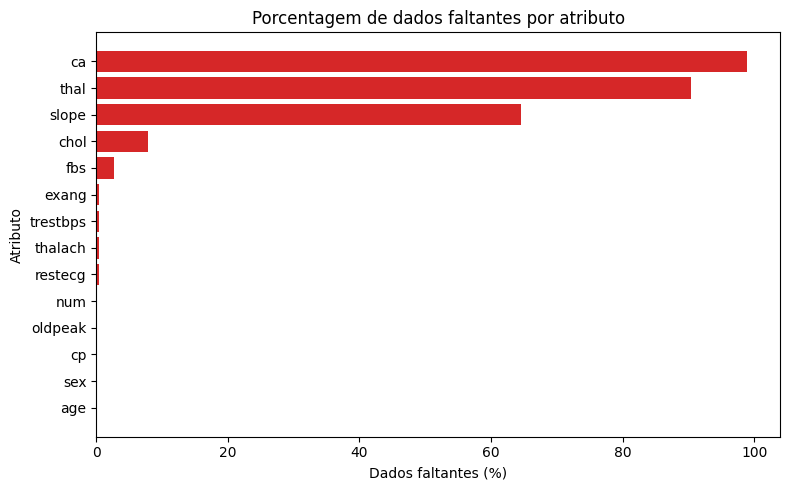

In [3]:
faltantes_pct = (df.isnull().sum() / len(df) * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(faltantes_pct.index, faltantes_pct.values, color="tab:red")
ax.set_xlabel("Dados faltantes (%)")
ax.set_ylabel("Atributo")
ax.set_title("Porcentagem de dados faltantes por atributo")
plt.tight_layout()
plt.show()


A partir do gráfico acima, nota-se que três colunas estão quase vazias: `ca`, `thal` e `slope`. Logo, não faz sentido considerar colunas assim, por isso as removo na linha abaixo. Além disso, ainda restam alguns dados faltantes em outras colunas, mas como não são expressivos não apago a coluna por inteiro, apenas esses dados sem informações que restaram.

In [4]:
ATRIBUTOS_NUMERICOS = ["age", "trestbps", "chol", "thalach", "oldpeak", "sex", "fbs", "exang"]
ATRIBUTOS_CATEGORICOS = ["cp", "restecg"]
ATRIBUTOS = ATRIBUTOS_NUMERICOS + ATRIBUTOS_CATEGORICOS
TARGET = ["num"]

df = df.reindex(ATRIBUTOS + TARGET, axis=1)
df = df.dropna()
df["restecg"] = df["restecg"].astype(int) 

print(f"Restaram {df.shape[0]} exemplos e {len(ATRIBUTOS)} atributos")

Restaram 261 exemplos e 10 atributos


### Normalização dos dados

In [5]:
df.describe()

,age,trestbps,chol,thalach,oldpeak,sex,fbs,exang,cp,restecg,num
count,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000,261.000000
mean,47.770115,132.639847,248.823755,139.226054,0.612261,0.735632,0.072797,0.318008,3.003831,0.226054,0.375479
std,7.842244,17.709857,65.667985,23.757401,0.931914,0.441843,0.260302,0.466597,0.970718,0.470935,0.485177
min,28.000000,92.000000,85.000000,82.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,42.000000,120.000000,208.000000,122.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,49.000000,130.000000,242.000000,140.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000
75%,54.000000,140.000000,280.000000,155.000000,1.000000,1.000000,0.000000,1.000000,4.000000,0.000000,1.000000
max,65.000000,200.000000,603.000000,190.000000,5.000000,1.000000,1.000000,1.000000,4.000000,2.000000,1.000000


Pela tabela, é possível notar que as escalas dos atributos são muito diferentes: `age` vai de 28 a 66 enquanto `chol` vai de 85 a 603.
Como o k-NN mede a distância, um atributo com números maiores pesa mais na distância do que um com números menores, mesmo que não haja atributos mais "importantes" que outros. Pensando nisso, testo a normalização dos dados posteriormente.

### Análise do alvo

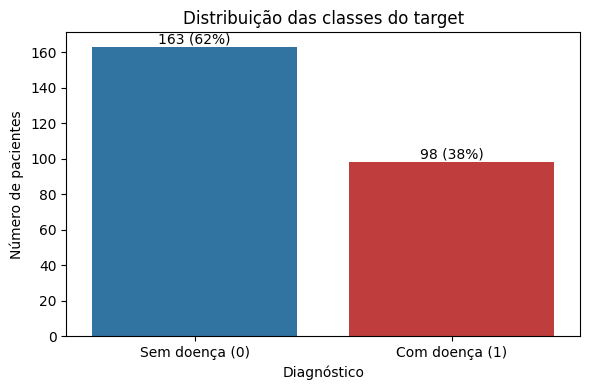

In [6]:
contagem = df["num"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="num", ax=ax, hue="num", palette=["tab:blue", "tab:red"], legend=False)
ax.set_xticks([0, 1], ["Sem doença (0)", "Com doença (1)"])
ax.set_xlabel("Diagnóstico")
ax.set_ylabel("Número de pacientes")
ax.set_title("Distribuição das classes do target")
for i, n in enumerate(contagem.values):
    ax.text(i, n + 2, f"{n} ({n / len(df):.0%})", ha="center")
plt.tight_layout()
plt.show()

Ao analisar o gráfico acima, nota-se que o target está desbalanceado, uma vez que a maior parte dos pacientes não possuem a doença. A partir disso, será necessário alterações futuras para correção deste desbalanço.

### Atributos que melhor distinguem as classes

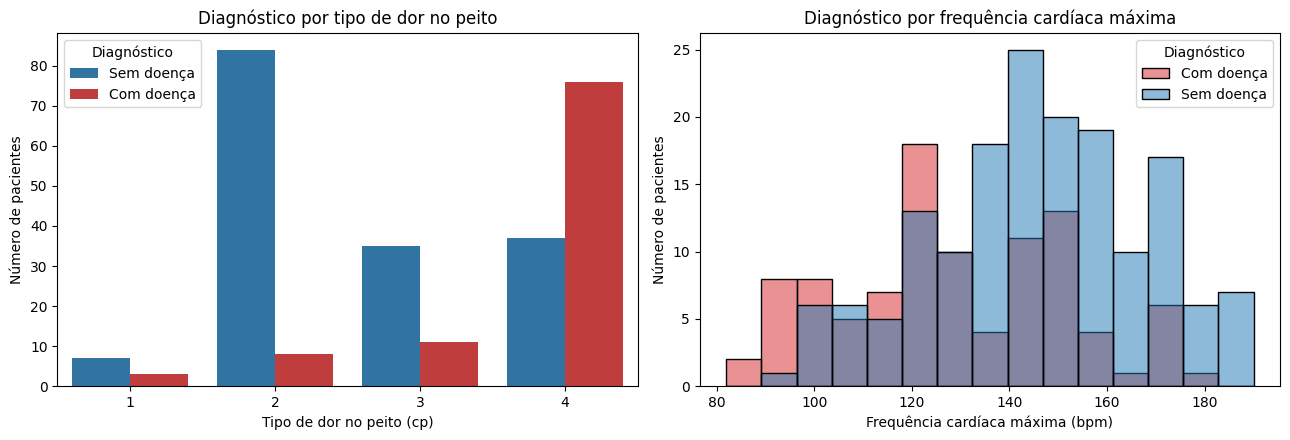

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="cp", hue="num", ax=ax1, palette=["tab:blue", "tab:red"])
ax1.set_xlabel("Tipo de dor no peito (cp)")
ax1.set_ylabel("Número de pacientes")
ax1.set_title("Diagnóstico por tipo de dor no peito")
ax1.legend(["Sem doença", "Com doença"], title="Diagnóstico")

sns.histplot(data=df, x="thalach", hue="num", ax=ax2, bins=15, palette=["tab:blue", "tab:red"])
ax2.set_xlabel("Frequência cardíaca máxima (bpm)")
ax2.set_ylabel("Número de pacientes")
ax2.set_title("Diagnóstico por frequência cardíaca máxima")
ax2.legend(["Com doença", "Sem doença"], title="Diagnóstico")

plt.tight_layout()
plt.show()

Ao comparar os dois gráficos acima, percebe-se que o tipo de dor no peito é o atributo que mais separa as classes: entre os pacientes assintomáticos (cp=4) a maioria tem a doença, enquanto entre os com angina atípica (cp=2) quase ninguém possui. 

A frequência cardíaca máxima também é bastante influente no diagnóstico: os doentes concentram-se em valores mais baixos de bpm, o que faz sentido lógico, já que a doença limita o esforço capaz de ser realizado pelo coração.

## Metodologia

### Divisão treino/teste

Aqui, sigo a estratégia de *holdout*, ou seja, reservo uma fração dos exemplos para teste, que o modelo não vê durante o treino e serve somente para medir o desempenho no final. Esta divisão é feita sobre os **Índices** do `DataFrame`, e depois recuperamos as linhas com `.loc`

Utilizo a proporção 20/80 para teste e treino, respectivamente. Além disso, é válido pontuar o papel da semente aleatória: que garante que o sorteio seja sempre o mesmo entre execuções. Vale destacar também que ela **não** é um hiperparâmetro e nunca deve ser variada para "forçar" um melhor resultado.

In [8]:
TAMANHO_TESTE = 0.2
SEMENTE_ALEATORIA = 61455

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()  
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

print(f"Treino: {len(df_treino)} exemplos ({y_treino.mean():.0%} com doença)")
print(f"Teste:  {len(df_teste)} exemplos ({y_teste.mean():.0%} com doença)")

Treino: 208 exemplos (39% com doença)
Teste:  53 exemplos (30% com doença)


### Métrica de desempenho

Neste trabalho, avaliarei o desempenho do meu modelo a partir da **matriz de confusão** e **acurácia**. No entanto, como meu alvo está desbalanceado: 62% dos pacientes não possuem a doença, então um modelo que respondesse "sem doença" para todos ainda teria uma acurácia de 62% sem identificar um único doente, será necessário utilizar a **acurácia balanceada**.

$$\text{acurácia balanceada} = \frac{1}{2}\left({\frac{VP}{VP + FN}} +
{\frac{VN}{VN + FP}}\right)$$ 

Ou seja, é a média entre a fração de doentes acertados e a fração de saudáveis acertados. Ela dá o
mesmo peso às duas classes, e qualquer modelo que ignore os atributos obtém exatamente 0,5. A acurácia comum continua sendo reportada para comparação, e a
matriz de confusão é mostrada para o baseline e para o melhor modelo, porque ela revela *onde* o modelo
erra. Por se tratar de um diagnóstico médico, o erro mais grave é o **falso negativo** (dizer que um doente está saudável).

In [9]:
ordem_labels = [0, 1]
NOMES_LABELS = ["Sem doença", "Com doença"]


def mostrar_matriz_confusao(y_verdadeiro, y_previsao, titulo):
    """Receita da disciplina: matriz de confusão como heatmap."""
    matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
    df_conf = pd.DataFrame(matriz_conf, NOMES_LABELS, NOMES_LABELS)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(df_conf, annot=True, annot_kws={"size": 16}, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_xlabel("Diagnóstico previsto")
    ax.set_ylabel("Diagnóstico verdadeiro")
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()
    return matriz_conf

### Modelo baseline

O modelo baseline é a nossa "régua", pois se trata do modelo mais simples que existe e que será usado como ponto de comparação para avaliar se nosso modelo está realmente aprendendo algo ou se está acertando pontos por acaso.

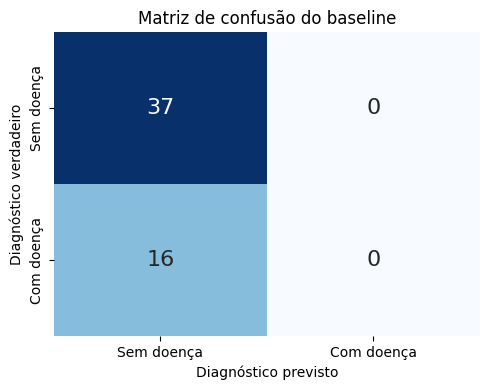

Acurácia = 69.81%
Acurácia balanceada = 50.00%


In [10]:
X_treino_numericos = df_treino.reindex(ATRIBUTOS_NUMERICOS, axis=1).values
X_teste_numericos = df_teste.reindex(ATRIBUTOS_NUMERICOS, axis=1).values

modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino_numericos, y_treino)

y_verdadeiro = y_teste
y_previsao_baseline = modelo_baseline.predict(X_teste_numericos)

matriz_baseline = mostrar_matriz_confusao(y_verdadeiro, y_previsao_baseline, "Matriz de confusão do baseline")

acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao_baseline)
acuracia_bal_baseline = balanced_accuracy_score(y_verdadeiro, y_previsao_baseline)
print(f"Acurácia = {(acuracia_baseline * 100):.2f}%")
print(f"Acurácia balanceada = {(acuracia_bal_baseline * 100):.2f}%")

### Preparação dos atributos: codificação e normalização

Como o scikit-learn só aceita números `cp` e `restecg` precisam ser codificados. Tendo isso em vista, testo dois codificadores: 

| Classe | O que faz | Indicado para |
|---|---|---|
| `OneHotEncoder` | Cria uma coluna 0/1 para cada categoria | Categorias nominais|
| `OrdinalEncoder` | Substitui cada categoria por um inteiro de 0 a n-1 | Categorias ordinais |

Uma observação adicional é que o `fit` é usado apenas para os dados de treino enquanto o `transform` é aplicado ao treino e ao teste. Isso porque se o normalizador aprendesse a média ou o valor máximo olhando também o teste, o teste deixaria de ser um conjunto nunca visto.

In [11]:
def preparar_atributos(codificador, normalizador=None):
    """Devolve (X_treino, X_teste) com os categóricos codificados e, opcionalmente, tudo normalizado."""
    X_treino_categoricos = df_treino.reindex(ATRIBUTOS_CATEGORICOS, axis=1).values
    X_teste_categoricos = df_teste.reindex(ATRIBUTOS_CATEGORICOS, axis=1).values

    codificador.fit(X_treino_categoricos)
    X_treino = np.hstack([X_treino_numericos, codificador.transform(X_treino_categoricos)])
    X_teste = np.hstack([X_teste_numericos, codificador.transform(X_teste_categoricos)])

    if normalizador is not None:
        normalizador.fit(X_treino)
        X_treino = normalizador.transform(X_treino)
        X_teste = normalizador.transform(X_teste)

    return X_treino, X_teste

Além disso, como comentei previamente em *Normalização dos dados* na sessão de *Análise exploratória dos dados*, os atributos estão em escalas muito destoantes, então testo três normalizadores, mais a opção de não normalizar:

| Normalização | Classe | O que faz |
|---|---|---| 
| Nenhuma | - | usa os atributos como estão | 
| Mínimo e máximo | `MinMaxScaler` | leva cada atributo para o intervalo $[0, 1]$ |
| Padrão (z-score) | `StandardScaler` | subtrai a média e divide pelo desvio padrão |
| Máximo absoluto | `MaxAbsScaler` | divide cada atributo pelo seu maior valor absoluto |

In [12]:
CODIFICADORES = {
    "One-hot": OneHotEncoder(sparse_output=False),
    "Ordinal": OrdinalEncoder(),
}

NORMALIZADORES = {
    "Sem normalização": None,
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
    "MaxAbsScaler": MaxAbsScaler(),
}

dados_preparados = {}
for nome_cod, codificador in CODIFICADORES.items():
    for nome_norm, normalizador in NORMALIZADORES.items():
        dados_preparados[(nome_norm, nome_cod)] = preparar_atributos(codificador, normalizador)

X_exemplo, _ = dados_preparados[("Sem normalização", "One-hot")]
print(f"Com one-hot, X tem {X_exemplo.shape[1]} colunas "
      f"({len(ATRIBUTOS_NUMERICOS)} numéricas + {X_exemplo.shape[1] - len(ATRIBUTOS_NUMERICOS)} da codificação)")

Com one-hot, X tem 15 colunas (8 numéricas + 7 da codificação)


### Conjunto de hiperparâmetros testados

| Hiperparâmetro | Valores |
|---|---|
| Normalização | nenhuma, `MinMaxScaler`, `StandardScaler`, `MaxAbsScaler` |
| Codificação | `OneHotEncoder`, `OrdinalEncoder` |
| Número de vizinhos $k$ | 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 31 |
| Função de distância | Euclidiana, Manhattan, Chebyshev | 

Ao total são 312 conjuntos de hiperparâmetros. Escolhi valores ímpares de $k$ para evitar empate na votação, já que o problema é binário, e
fui de 1 até 31 para cobrir tanto o modelo que "decora" o treino quanto o que suaviza demais.

As três distâncias são casos da distância de Minkowski: a **Euclidiana** é a distância em linha reta,
a **Manhattan** soma as diferenças absolutas em cada atributo, e a **Chebyshev** considera apenas a
maior diferença entre todos os atributos, ignorando as demais.

In [13]:
VALORES_K = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 25, 31]
DISTANCIAS = ["euclidean", "manhattan", "chebyshev"]

resultados = []
for (nome_norm, nome_cod), (X_treino, X_teste) in dados_preparados.items():
    for k in VALORES_K:
        for distancia in DISTANCIAS:
            modelo_knn = KNeighborsClassifier(n_neighbors=k, metric=distancia)
            modelo_knn.fit(X_treino, y_treino)
            y_previsao = modelo_knn.predict(X_teste)

            resultados.append({
                "normalizacao": nome_norm,
                "codificacao": nome_cod,
                "k": k,
                "distancia": distancia.capitalize(),
                "acuracia": accuracy_score(y_verdadeiro, y_previsao),
                "acuracia_balanceada": balanced_accuracy_score(y_verdadeiro, y_previsao),
            })

df_resultados = pd.DataFrame(resultados)
print(f"{len(df_resultados)} conjuntos de hiperparâmetros avaliados")
df_resultados.head()

312 conjuntos de hiperparâmetros avaliados


,normalizacao,codificacao,k,distancia,acuracia,acuracia_balanceada
0,Sem normalização,One-hot,1,Euclidean,0.528302,0.449324
1,Sem normalização,One-hot,1,Manhattan,0.547170,0.462838
2,Sem normalização,One-hot,1,Chebyshev,0.509434,0.453547
3,Sem normalização,One-hot,3,Euclidean,0.528302,0.431588
4,Sem normalização,One-hot,3,Manhattan,0.566038,0.476351


## Experimentos

### Experimento 1 - Normalização

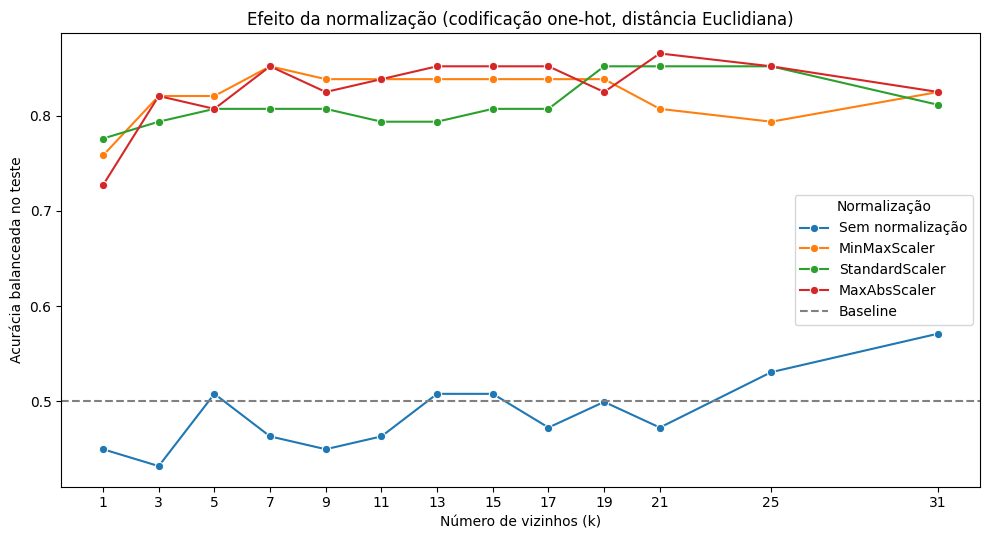

,Acurácia média,Acurácia balanceada média
normalizacao,,
MaxAbsScaler,0.836,0.807
MinMaxScaler,0.834,0.802
Sem normalização,0.609,0.518
StandardScaler,0.817,0.791


In [14]:
mesma_codificacao = df_resultados["codificacao"] == "One-hot"
mesma_distancia = df_resultados["distancia"] == "Euclidean"
recorte = df_resultados[mesma_codificacao & mesma_distancia]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=recorte, x="k", y="acuracia_balanceada", hue="normalizacao", marker="o", ax=ax)
ax.axhline(0.5, color="gray", linestyle="--", label="Baseline")
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("Acurácia balanceada no teste")
ax.set_title("Efeito da normalização (codificação one-hot, distância Euclidiana)")
ax.set_xticks(VALORES_K)
ax.legend(title="Normalização")
plt.tight_layout()
plt.show()

resumo = df_resultados.groupby("normalizacao")[["acuracia", "acuracia_balanceada"]].mean()
resumo.columns = ["Acurácia média", "Acurácia balanceada média"]
resumo.round(3)

A normalização é o efeito mais forte de todo o trabalho. Sem normalizar, a acurácia balanceada fica
entre 0,43 e 0,57 para qualquer k, na média, 0,515, ou seja, exatamente o nível do baseline. Com
qualquer um dos três normalizadores ela sobe para a faixa de 0,73 a 0,87.

A explicação é geométrica e confirma o que eu havia previsto ao olhar o **describe**. Sem normalização,
a distância entre dois pacientes é dominada pelo colesterol, que varia em centenas de mg/dL, enquanto
`oldpeak` (de 0 a 5) e as colunas 0/1 quase não contam. O $k$-NN passa a escolher vizinhos pelo
colesterol, que é justamente um dos atributos menos ligados ao diagnóstico. Normalizar devolve importância aos
atributos que importam.

Entre os três normalizadores as diferenças são pequenas (médias entre 0,79 e 0,81) e ficam dentro do
ruído esperado para um teste de 53 exemplos. `MaxAbsScaler` e `MinMaxScaler` ficaram ligeiramente
acima; como nenhum atributo aqui é negativo, os dois fazem quase a mesma coisa, e o `StandardScaler` é
o único que centraliza os dados na média.

### Experimento 2 - Número de vizinhos e função de distância

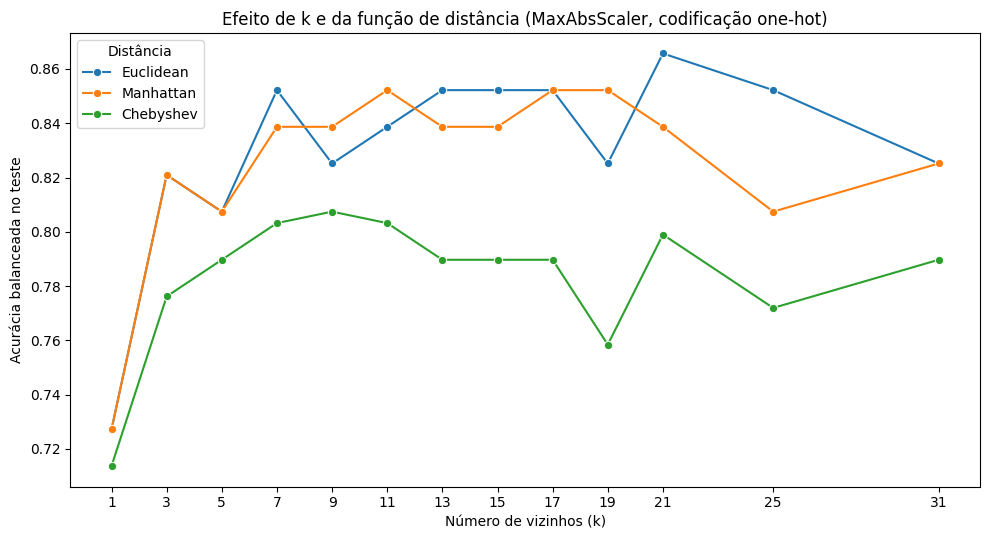

,Acurácia média,Acurácia balanceada média
distancia,,
Chebyshev,0.803,0.756
Euclidean,0.843,0.822
Manhattan,0.841,0.822


In [15]:
mesma_normalizacao = df_resultados["normalizacao"] == "MaxAbsScaler"
mesma_codificacao = df_resultados["codificacao"] == "One-hot"
recorte = df_resultados[mesma_normalizacao & mesma_codificacao]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=recorte, x="k", y="acuracia_balanceada", hue="distancia", marker="o", ax=ax)
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("Acurácia balanceada no teste")
ax.set_title("Efeito de k e da função de distância (MaxAbsScaler, codificação one-hot)")
ax.set_xticks(VALORES_K)
ax.legend(title="Distância")
plt.tight_layout()
plt.show()

normalizadas = df_resultados[df_resultados["normalizacao"] != "Sem normalização"]
resumo = normalizadas.groupby("distancia")[["acuracia", "acuracia_balanceada"]].mean()
resumo.columns = ["Acurácia média", "Acurácia balanceada média"]
resumo.round(3)

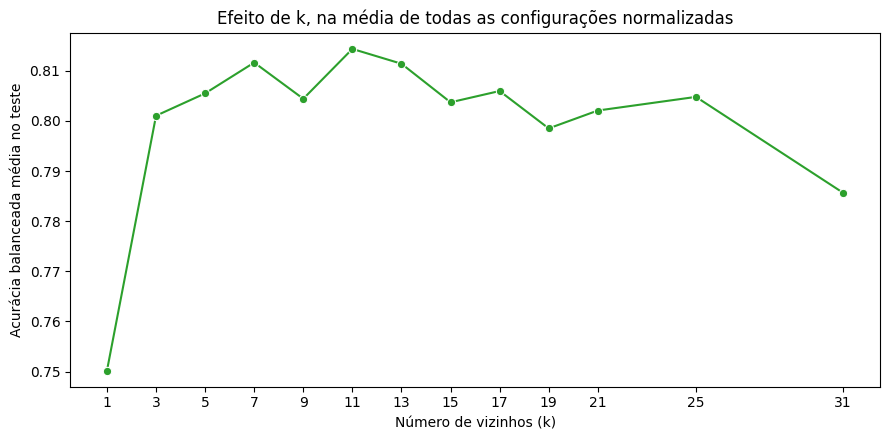

In [16]:
resumo_k = normalizadas.groupby("k")["acuracia_balanceada"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(x=resumo_k.index, y=resumo_k.values, marker="o", ax=ax, color="tab:green")
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("Acurácia balanceada média no teste")
ax.set_title("Efeito de k, na média de todas as configurações normalizadas")
ax.set_xticks(VALORES_K)
plt.tight_layout()
plt.show()

Para o **Número de vizinhos.** o pior resultado é sempre k = 1 (média de 0,755 entre as configurações
normalizadas): com um único vizinho, um paciente atípico do treino decide sozinho o diagnóstico, e o
modelo herda todo o ruído dos dados. De k = 3 em diante a votação suaviza esse ruído e a média sobe
para um platô em torno de 0,80, que se mantém até k aproximadamente 15. Para k grande a média cai de novo
(0,779 em k = 31): com 208 exemplos de treino, dos quais 82 são doentes, uma vizinhança tão grande
começa a incluir pacientes pouco parecidos, e a classe majoritária vence votações que não deveria. 

Já na **Função de distância.** a Euclidiana e a Manhattan empatam (0,822 as duas). A Chebyshev é claramente pior
(0,752) para praticamente todo k, e a razão está na definição dela: usa apenas o atributo em que dois
pacientes mais diferem e descarta todos os outros. Assim, dois pacientes que diferem muito em um único
exame ficam tão distantes quanto dois que diferem muito em todos. Euclidiana e Manhattan somam a
contribuição de todos os atributos, a Chebyshev joga a maior parte da informação fora.

### Experimento 3 - Codificação dos atributos categóricos

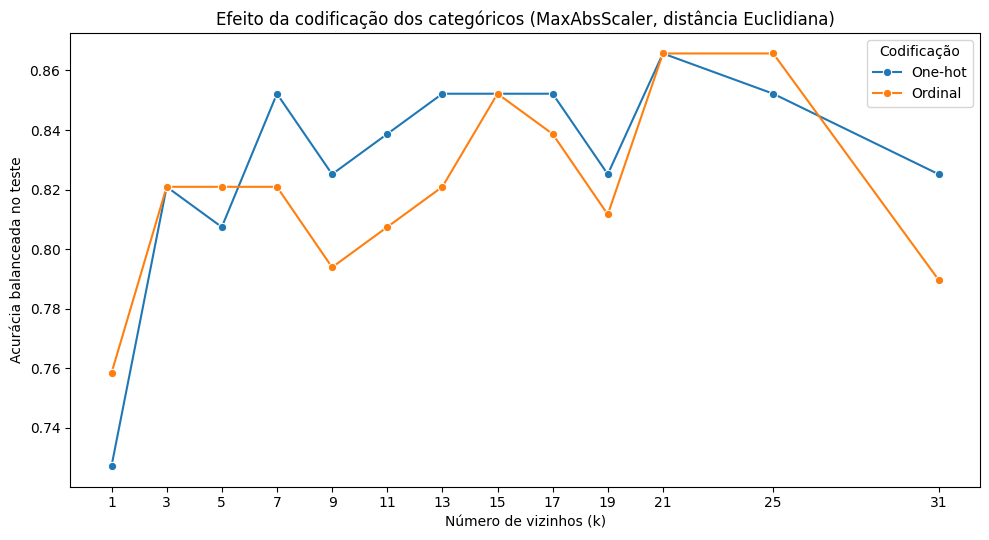

codificacao,One-hot,Ordinal
distancia,,
Chebyshev,0.783,0.752
Euclidean,0.830,0.821
Manhattan,0.826,0.829


In [17]:
esma_normalizacao = df_resultados["normalizacao"] == "MaxAbsScaler"
mesma_distancia = df_resultados["distancia"] == "Euclidean"
recorte = df_resultados[mesma_normalizacao & mesma_distancia]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.lineplot(data=recorte, x="k", y="acuracia_balanceada", hue="codificacao", marker="o", ax=ax)
ax.set_xlabel("Número de vizinhos (k)")
ax.set_ylabel("Acurácia balanceada no teste")
ax.set_title("Efeito da codificação dos categóricos (MaxAbsScaler, distância Euclidiana)")
ax.set_xticks(VALORES_K)
ax.legend(title="Codificação")
plt.tight_layout()
plt.show()

cruzamento = df_resultados[mesma_normalizacao].pivot_table(
    index="distancia", columns="codificacao", values="acuracia_balanceada"
)
cruzamento.round(3)

Eu esperava que o *one-hot* fosse melhor, por não inventar uma ordem entre os tipos de dor. Na prática
as duas codificações são indistinguíveis: as curvas se cruzam repetidamente e as médias gerais são
0,798 (*one-hot*) e 0,799 (ordinal).

Existe uma explicação para o ordinal não ter prejudicado. A numeração original de `cp` coloca, por
coincidência, o tipo de dor mais associado à doença (`cp = 4`, assintomático) no extremo da escala, e o
menos associado (`cp = 2`) no meio. A ordem artificial 1 < 2 < 3 < 4 acabou separando os pacientes de
maior risco dos de menor risco. Com outra numeração o resultado poderia ser bem diferente, o que
reforça que o *one-hot* continua sendo a escolha segura para atributos nominais, mesmo quando não faz
diferença.

## Resultados e discussão

In [18]:
top10 = (df_resultados.sort_values(["acuracia_balanceada", "acuracia"], ascending=False)
         .head(10).reset_index(drop=True))
top10.round(3)

,normalizacao,codificacao,k,distancia,acuracia,acuracia_balanceada
0,MaxAbsScaler,One-hot,21,Euclidean,0.887,0.866
1,MaxAbsScaler,Ordinal,21,Euclidean,0.887,0.866
2,MaxAbsScaler,Ordinal,21,Manhattan,0.887,0.866
3,MaxAbsScaler,Ordinal,25,Euclidean,0.887,0.866
4,MinMaxScaler,One-hot,7,Euclidean,0.868,0.852
5,MinMaxScaler,One-hot,11,Manhattan,0.868,0.852
6,StandardScaler,One-hot,19,Euclidean,0.868,0.852
7,StandardScaler,One-hot,21,Euclidean,0.868,0.852
8,StandardScaler,One-hot,25,Euclidean,0.868,0.852
9,MaxAbsScaler,One-hot,7,Euclidean,0.868,0.852


Os dez melhores conjuntos estão todos entre 0,852 e 0,866 de acurácia balanceada — uma diferença menor
que o efeito de um único paciente do teste. Isso significa que **não há um vencedor claro**: várias
combinações são equivalentes, e o que os experimentos distinguem com segurança são os efeitos grandes. Mesmo assim, tomo o primeiro da lista como modelo final e
mostro a matriz de confusão dele.

Melhor conjunto de hiperparâmetros:
  normalização = MaxAbsScaler
  codificação  = One-hot
  k            = 21
  distância    = Euclidean


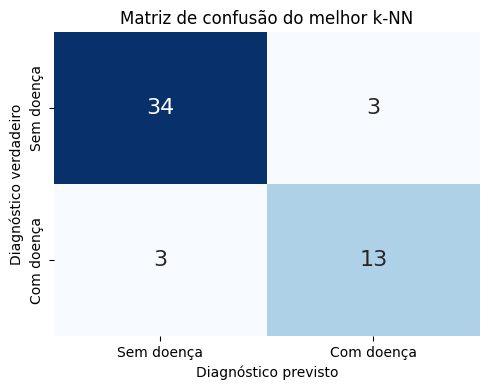

array([34,  3,  3, 13])

In [19]:
melhor = top10.iloc[0]
print("Melhor conjunto de hiperparâmetros:")
print(f"  normalização = {melhor['normalizacao']}")
print(f"  codificação  = {melhor['codificacao']}")
print(f"  k            = {melhor['k']}")
print(f"  distância    = {melhor['distancia']}")

X_treino, X_teste = dados_preparados[(melhor["normalizacao"], melhor["codificacao"])]
modelo_final = KNeighborsClassifier(n_neighbors=int(melhor["k"]), metric=melhor["distancia"].lower())
modelo_final.fit(X_treino, y_treino)
y_previsao_final = modelo_final.predict(X_teste)

matriz_final = mostrar_matriz_confusao(y_verdadeiro, y_previsao_final, "Matriz de confusão do melhor k-NN")

matriz_final.ravel()

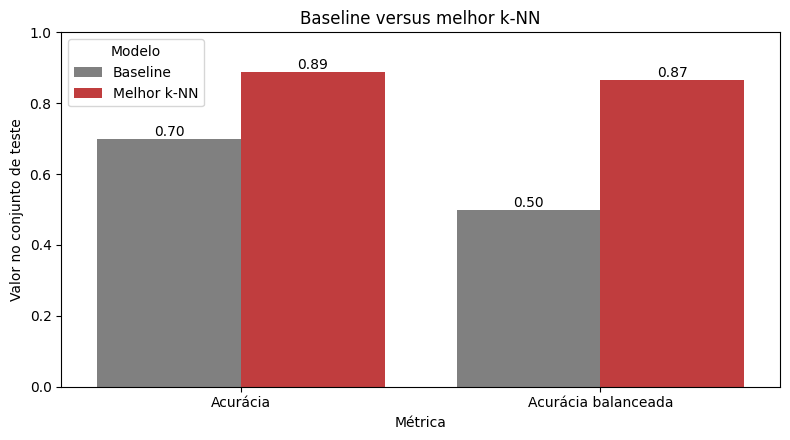

In [20]:
comparacao = pd.DataFrame({
    "Modelo": ["Baseline", "Melhor k-NN", "Baseline", "Melhor k-NN"],
    "Métrica": ["Acurácia", "Acurácia", "Acurácia balanceada", "Acurácia balanceada"],
    "Valor": [
        acuracia_baseline,
        accuracy_score(y_verdadeiro, y_previsao_final),
        acuracia_bal_baseline,
        balanced_accuracy_score(y_verdadeiro, y_previsao_final),
    ],
})

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=comparacao, x="Métrica", y="Valor", hue="Modelo", ax=ax, palette=["gray", "tab:red"])
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor no conjunto de teste")
ax.set_title("Baseline versus melhor k-NN")
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
plt.show()

O melhor k-NN (`MaxAbsScaler`, *one-hot*, k = 21, distância Euclidiana) tem acurácia de 88,68% e
acurácia balanceada de 86,57%, contra 69,81% e 50% do baseline. Dos 16 doentes do conjunto de teste
ele identifica 13, e dos 37 saudáveis acerta 34. Os 3
falsos negativos são o erro mais importante desse resultado: representariam pacientes doentes
liberados como saudáveis.

Voltando à pergunta que motivou o trabalho, o resultado indica que os exames clínicos de rotina
carregam bastante informação sobre o diagnóstico, o suficiente para um dos algoritmos mais simples de
aprendizado supervisionado acertar quase nove em cada dez pacientes, e para superar o baseline por uma
margem larga nas duas métricas.

## Conclusões e principais aprendizados

**Normalizar é obrigatório no $k$-NN.** Sem normalização o modelo fica no nível do baseline (acurácia
balanceada média de 0,515) com qualquer um dos normalizadores ela sobe para cerca de 0,80. Sem uma
escala comum, a distância mede unidade de medida, e não semelhança clínica.

**A função de distância importa quando ela descarta informação.** Euclidiana e Manhattan empatam
(0,822) já a de Chebyshev, que olha um único atributo por vez, é pior (0,752).

**O número de vizinhos importa nos extremos.** k = 1 é sempre o pior, existe um platô amplo entre
k = 3 e k = 15, e k muito grande volta a piorar. Dentro do platô, a escolha é indiferente na
prática.

**A codificação dos categóricos importou menos do que eu esperava**, por uma coincidência da numeração
de `cp`, que colocou o tipo de maior risco no extremo da escala. Ainda assim, o *one-hot* segue sendo a
escolha correta para atributos nominais.

**A escolha da métrica precisa ser feita com cuidado.** O baseline tem 69,81% de acurácia sem detectar
um único doente, e é a acurácia balanceada que deixa esse problema visível.

**Distância de Chebyshev.** A partir deste trabalho, aprendi sobre essa métrica de distância que não conhecia. Ao procurar sobre como expandir meus conjuntos de hiperparâmetros me deparei com algumas alternativas de funções de distâncias, tendo escolhido utilizar esta puramente por acaso. 

**Acúracia balanceada.** Ao ler o notebook do professor Cassar [1] sobre como a acurácia pode ser enganosa caso o target esteja desbalanceado e notar que meu target estava desbalanceado, procurei soluções para o caso e me deparei com o conceito de "acurácia balanceada". Como me pareceu razóavel e tive aprovação do professor, utilizei-a no presente trabalho.

## Descrição do uso de IA neste trabalho

1. **Estudo do material da disciplina.** Enviei os cinco notebooks da ATP-203 e pedi uma apostila resumida e em
linguagem simples, que usei para estudar e consultar durante a execução do trabalho. 

2. **Avaliação do conjunto de dados.** Enviei o `data.csv` e pedi uma checagem contra os critérios do
enunciado. A ferramenta apontou os valores `?`, as três colunas quase vazias, o desbalanceamento do
alvo e o espaço extra no nome da coluna `num`, e sugeriu citar a fonte original (UCI) em vez do
Kaggle. Perguntei se valia trocar por um conjunto mais simples e decidi manter este. 

3. **Correção gramatical.** Buscando maior clareza em minhas explicações, visto que as pessoas precisam ler e entender o que estou falando além dos códigos, consultei a IA para conferir se minhas falas estavam coesas e coerentes. 

4. **Ajuda com os gráficos.** Para melhor visualização dos dados, consultei a ferramenta para saber, de maneira mais objetiva, quais gráficos plotar de acordo com o que eu queria representar, além de como realizá-los. 

5. **Aumento dos hiperparâmetros.** Utilizei a IA para saber o que mais eu poderia fazer que pudesse aumentar meus conjuntos de hiperparâmetros: ai que descobri a distância de Chebyshev como mais uma alternativa de distância. 

6. **Referências.** Mandei o material que utilizei para realizar o trabalho e pedi que gerasse as referências no padrão ABNT.

## Referências

CASSAR, Daniel R. ATP-203 – Aprendizado de Máquina: notebooks 1.0 (tratamento de dados com
pandas), 2.0 (divisão em treino e teste), 3.0 (modelo linear e baseline), 4.0 (árvore de decisão
e floresta aleatória) e 5.0 (classificação binária). [2026]. Notebooks Jupyter. Material didático
da disciplina ATP-203 – Ilum Escola de Ciência, Centro Nacional de Pesquisa em Energia e
Materiais, Campinas. [1]

APRENDER ESTATÍSTICA FÁCIL. **O que é: Acurácia Balanceada — definição e importância**. [s.d.].
Disponível em: https://estatisticafacil.org/glossario/o-que-e-acuracia-balanceada-definicao-e-importancia/. 


SCIKIT-LEARN DEVELOPERS. **sklearn.metrics.DistanceMetric**. Documentação do scikit-learn,
versão 1.9.1, 2026. Disponível em:
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html. 


SCIKIT-LEARN DEVELOPERS. **sklearn.neighbors.KNeighborsClassifier**. Documentação do
scikit-learn, versão 1.9.1, 2026. Disponível em:
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html. 


ANTHROPIC. Claude [assistente de IA]. Versão Fable 5.1. Agosto–setembro de 2026. Disponível em:https://claude.ai. 


RADEČIĆ, Dario. Como visualizar modelos de aprendizado de máquina: da regressão linear às redes
neurais. DataCamp, 24 out. 2024. Disponível em:
https://www.datacamp.com/pt/tutorial/visualize-machine-learning-models. 